Análise comparativa do desempenho de diferentes modelos de LLMs na prova do POSCOMP 2019-2023.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

In [ ]:

plt.style.use('default')
sns.set_palette("pastel")
%matplotlib inline

dir_graficos = Path.cwd() / 'graficos_2019_2023'
dir_graficos.mkdir(exist_ok=True)

subpastas = ["01_desempenho_geral", "02_desempenho_por_assunto", "03_desempenho_por_conteudo", "04_desempenho_por_ano"]
for subpasta in subpastas:
    (dir_graficos / subpasta).mkdir(exist_ok=True)

In [ ]:

df = pd.read_excel('resultados.xlsx')
print("Dados originais:")
print(df.head())
print(df.info())

#exclui questoes anuladas
df_filtrado = df[(df['Ano'] >= 2019) & (df['Ano'] <= 2023)].copy()
df_filtrado = df_filtrado[df_filtrado['Gabarito'] != '*'].copy()

print(f"\nTotal de questoes: {len(df_filtrado)}")
print(f"Distribuição por ano:")
print(df_filtrado['Ano'].value_counts().sort_index())
print(f"\nQuestões anuladas removidas: {len(df[(df['Ano'] >= 2019) & (df['Ano'] <= 2023) & (df['Gabarito'] == '*')])}") 

Dados originais:
   ID  Questão  Gabarito     Assunto   Ano GPT 5 Gemini 2.5 Flash  \
0   1         1        A  Matemática  2019     A                A   
1   2         2        B  Matemática  2019     B                B   
2   3         3        D  Matemática  2019     D                D   
3   4         4        E  Matemática  2019     E                E   
4   5         5        E  Matemática  2019     E                E   

  Claude Sonnet 4 Deepseek v3.1 Contem Imagem Contem Formula Contem Tabela  \
0               A             A             0              1             0   
1               B             B             0              1             0   
2               D             D             0              1             0   
3               E             E             0              1             0   
4               E             E             0              1             0   

  Contem Codigo  
0             0  
1             0  
2             0  
3             0  
4        

GPT 5: 191/207 = 92.27%
Gemini 2.5 Flash: 182/207 = 87.92%
Claude Sonnet 4: 186/207 = 89.86%
Deepseek v3.1: 190/207 = 91.79%


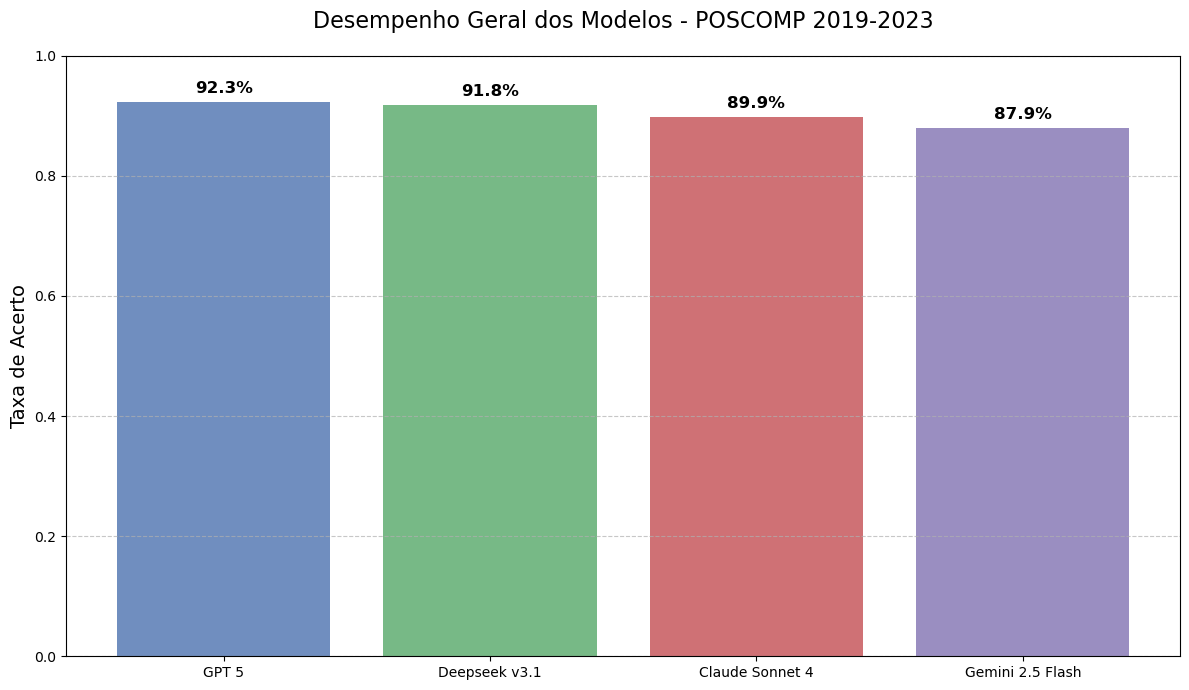

In [11]:
modelos = ['GPT 5', 'Gemini 2.5 Flash', 'Claude Sonnet 4', 'Deepseek v3.1']

# Desempenho geral (2019-2023)
desempenho = {}
for modelo in modelos:
    acertos = (df_filtrado[modelo] == df_filtrado['Gabarito']).sum()
    total = len(df_filtrado)
    desempenho[modelo] = acertos / total
    print(f"{modelo}: {acertos}/{total} = {desempenho[modelo]:.2%}")

plt.figure(figsize=(12, 7))
modelos_ordenados = sorted(desempenho, key=desempenho.get, reverse=True)
valores_ordenados = [desempenho[m] for m in modelos_ordenados]

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
bars = plt.bar(modelos_ordenados, valores_ordenados, color=colors, alpha=0.8)
plt.ylabel('Taxa de Acerto', fontsize=14)
plt.title('Desempenho Geral dos Modelos - POSCOMP 2019-2023', fontsize=16, pad=20)
plt.ylim(0, 1)

for bar, valor in zip(bars, valores_ordenados):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{valor:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(dir_graficos / '01_desempenho_geral' / 'desempenho_geral_2019_2023.png', 
            dpi=300, bbox_inches='tight')
plt.savefig(dir_graficos / '01_desempenho_geral' / 'desempenho_geral_2019_2023.pdf', 
            bbox_inches='tight')
plt.show()


ANÁLISE POR ANO

Ano: 2019 (69 questões)
  GPT 5: 62/69 = 89.86%
  Gemini 2.5 Flash: 59/69 = 85.51%
  Claude Sonnet 4: 61/69 = 88.41%
  Deepseek v3.1: 64/69 = 92.75%

Ano: 2022 (69 questões)
  GPT 5: 63/69 = 91.30%
  Gemini 2.5 Flash: 61/69 = 88.41%
  Claude Sonnet 4: 63/69 = 91.30%
  Deepseek v3.1: 63/69 = 91.30%

Ano: 2023 (69 questões)
  GPT 5: 66/69 = 95.65%
  Gemini 2.5 Flash: 62/69 = 89.86%
  Claude Sonnet 4: 62/69 = 89.86%
  Deepseek v3.1: 63/69 = 91.30%


<Figure size 1400x800 with 0 Axes>

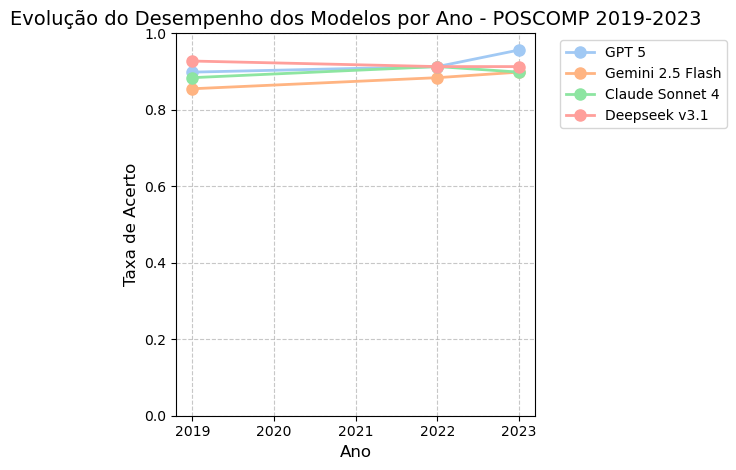

In [ ]:
# Desempenho por ano
print("\n" + "="*60)
print("ANÁLISE POR ANO")
print("="*60)

anos = sorted(df_filtrado['Ano'].unique())
desempenho_anos = pd.DataFrame(index=anos, columns=modelos)

for ano in anos:
    subset = df_filtrado[df_filtrado['Ano'] == ano]
    print(f"\nAno: {ano} ({len(subset)} questões)")
    for modelo in modelos:
        acertos = (subset[modelo] == subset['Gabarito']).sum()
        taxa = acertos / len(subset)
        desempenho_anos.loc[ano, modelo] = taxa
        print(f"  {modelo}: {acertos}/{len(subset)} = {taxa:.2%}")

plt.figure(figsize=(14, 8))
ax = desempenho_anos.plot(kind='line', marker='o', linewidth=2, markersize=8)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Taxa de Acerto', fontsize=12)
plt.title('Evolução do Desempenho dos Modelos por Ano - POSCOMP 2019-2023', fontsize=14)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(dir_graficos / '04_desempenho_por_ano' / 'desempenho_por_ano_linha.png', 
            dpi=300, bbox_inches='tight')
plt.savefig(dir_graficos / '04_desempenho_por_ano' / 'desempenho_por_ano_linha.pdf', 
            bbox_inches='tight')
plt.show()


ANÁLISE POR ASSUNTO

Assunto: Matemática (59 questões)
  GPT 5: 57/59 = 96.61%
  Gemini 2.5 Flash: 55/59 = 93.22%
  Claude Sonnet 4: 57/59 = 96.61%
  Deepseek v3.1: 59/59 = 100.00%

Assunto: Fundamentos da Computação (88 questões)
  GPT 5: 79/88 = 89.77%
  Gemini 2.5 Flash: 75/88 = 85.23%
  Claude Sonnet 4: 75/88 = 85.23%
  Deepseek v3.1: 78/88 = 88.64%

Assunto: Tecnologia de Computadores (60 questões)
  GPT 5: 55/60 = 91.67%
  Gemini 2.5 Flash: 52/60 = 86.67%
  Claude Sonnet 4: 54/60 = 90.00%
  Deepseek v3.1: 53/60 = 88.33%


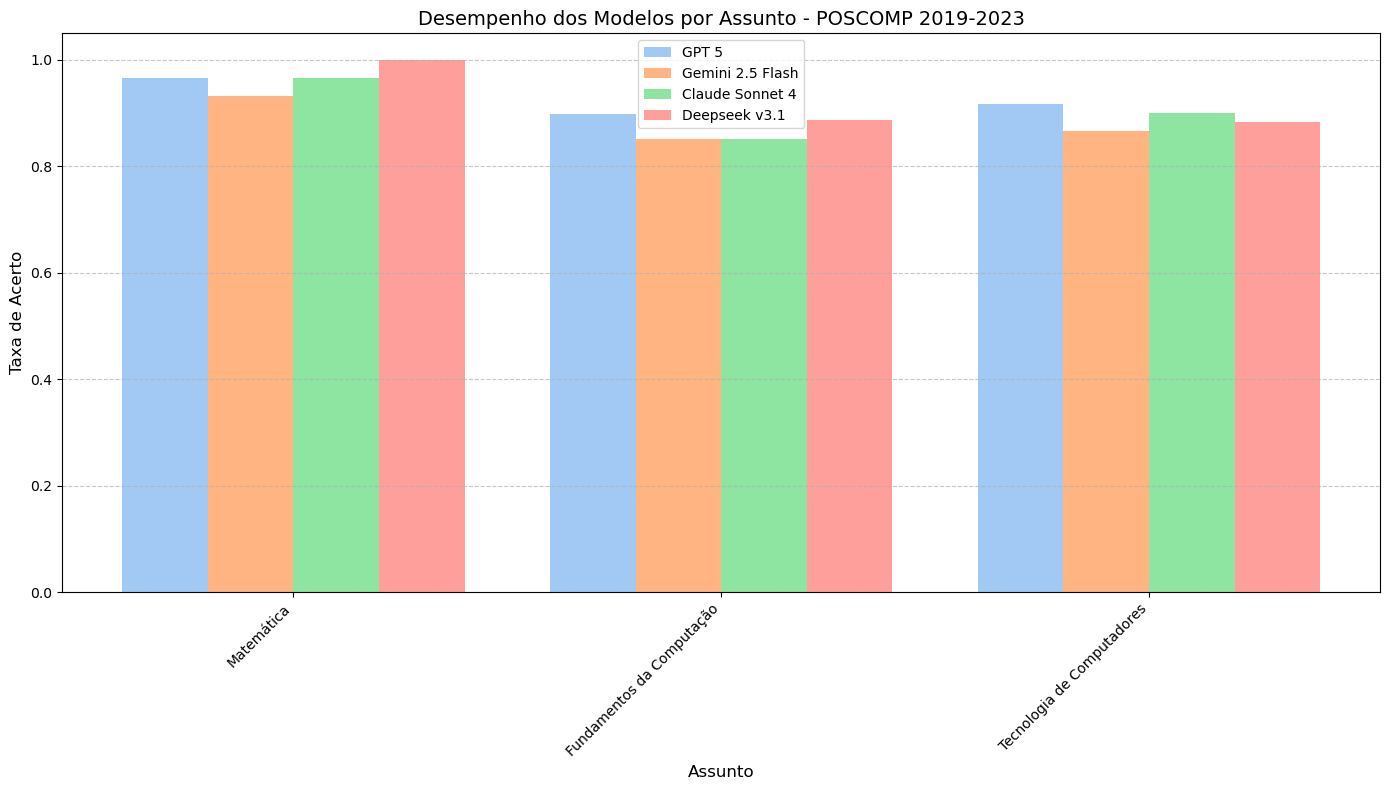

In [13]:
# Desempenho por assunto
print("\n" + "="*60)
print("ANÁLISE POR ASSUNTO")
print("="*60)

assuntos = df_filtrado['Assunto'].unique()
desempenho_assuntos = pd.DataFrame(index=assuntos, columns=modelos)
contagem_assuntos = {}

for assunto in assuntos:
    subset = df_filtrado[df_filtrado['Assunto'] == assunto]
    contagem_assuntos[assunto] = len(subset)
    print(f"\nAssunto: {assunto} ({len(subset)} questões)")
    for modelo in modelos:
        acertos = (subset[modelo] == subset['Gabarito']).sum()
        taxa = acertos / len(subset)
        desempenho_assuntos.loc[assunto, modelo] = taxa
        print(f"  {modelo}: {acertos}/{len(subset)} = {taxa:.2%}")

plt.figure(figsize=(14, 8))
x = np.arange(len(assuntos))
width = 0.2

for i, modelo in enumerate(modelos):
    plt.bar(x + i*width, desempenho_assuntos[modelo].values, width, label=modelo)

plt.xlabel('Assunto', fontsize=12)
plt.ylabel('Taxa de Acerto', fontsize=12)
plt.title('Desempenho dos Modelos por Assunto - POSCOMP 2019-2023', fontsize=14)
plt.xticks(x + width*1.5, assuntos, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(dir_graficos / '02_desempenho_por_assunto' / 'desempenho_assuntos_barras.png', 
            dpi=300, bbox_inches='tight')
plt.savefig(dir_graficos / '02_desempenho_por_assunto' / 'desempenho_assuntos_barras.pdf', 
            bbox_inches='tight')
plt.show()


ANÁLISE POR TIPO DE CONTEÚDO

Tipo: Imagem (10 questões)
  GPT 5: 8/10 = 80.00%
  Gemini 2.5 Flash: 4/10 = 40.00%
  Claude Sonnet 4: 6/10 = 60.00%
  Deepseek v3.1: 6/10 = 60.00%

Tipo: Fórmula (45 questões)
  GPT 5: 44/45 = 97.78%
  Gemini 2.5 Flash: 40/45 = 88.89%
  Claude Sonnet 4: 40/45 = 88.89%
  Deepseek v3.1: 43/45 = 95.56%

Tipo: Tabela (10 questões)
  GPT 5: 10/10 = 100.00%
  Gemini 2.5 Flash: 9/10 = 90.00%
  Claude Sonnet 4: 9/10 = 90.00%
  Deepseek v3.1: 9/10 = 90.00%

Tipo: Código (11 questões)
  GPT 5: 11/11 = 100.00%
  Gemini 2.5 Flash: 11/11 = 100.00%
  Claude Sonnet 4: 10/11 = 90.91%
  Deepseek v3.1: 11/11 = 100.00%

Tipo: Apenas Texto (137 questões)
  GPT 5: 124/137 = 90.51%
  Gemini 2.5 Flash: 123/137 = 89.78%
  Claude Sonnet 4: 125/137 = 91.24%
  Deepseek v3.1: 125/137 = 91.24%


<Figure size 1400x800 with 0 Axes>

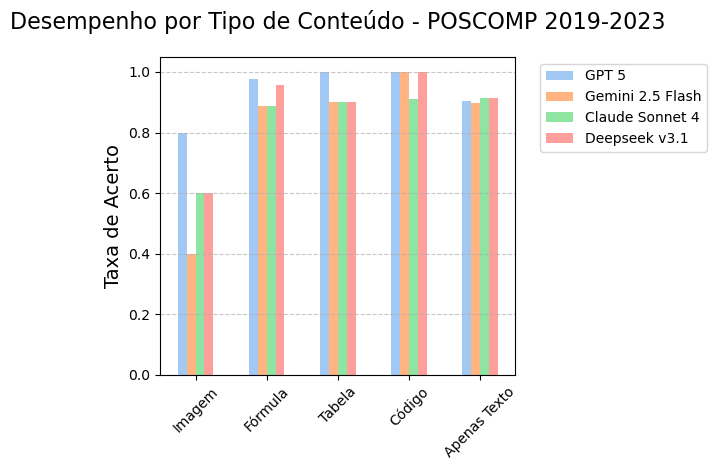

<Figure size 1000x600 with 0 Axes>

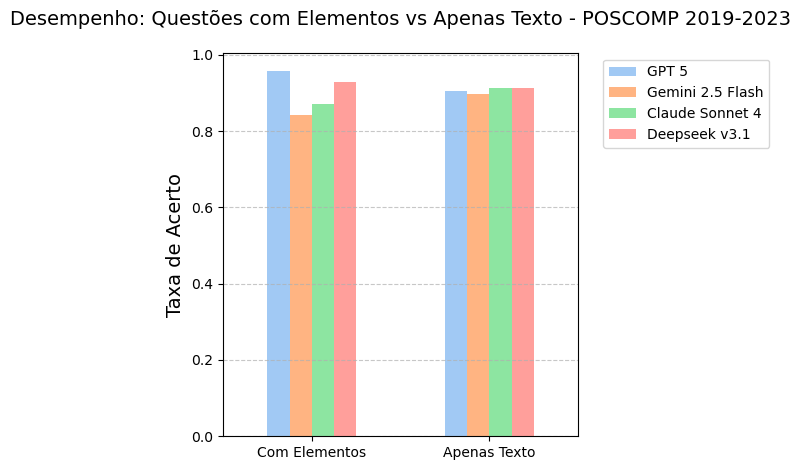


DISTRIBUIÇÃO DE TIPOS DE CONTEÚDO
Total de questões: 207
Imagem: 10 questões (4.8%)
Fórmula: 45 questões (21.7%)
Tabela: 10 questões (4.8%)
Código: 11 questões (5.3%)
Apenas Texto: 137 questões (66.2%)
Com elementos: 70 questões (33.8%)

Sobreposição de tipos de conteúdo:
Imagem + Fórmula: 1 questões
Fórmula + Tabela: 4 questões
Fórmula + Código: 1 questões
Tabela + Código: 1 questões


In [ ]:
# Desempenho por tipo de conteúdo
print("\n" + "="*60)
print("ANÁLISE POR TIPO DE CONTEÚDO")
print("="*60)

tipos_conteudo = ['Contem Imagem', 'Contem Formula', 'Contem Tabela', 'Contem Codigo']
nomes = ['Imagem', 'Fórmula', 'Tabela', 'Código', 'Apenas Texto']

desempenho_tipos = pd.DataFrame(index=nomes, columns=modelos)

for i, tipo in enumerate(tipos_conteudo):
    subset = df_filtrado[df_filtrado[tipo] == 1]
    print(f"\nTipo: {nomes[i]} ({len(subset)} questões)")
    
    for modelo in modelos:
        if len(subset) > 0:
            acertos = (subset[modelo] == subset['Gabarito']).sum()
            taxa = acertos / len(subset)
            desempenho_tipos.loc[nomes[i], modelo] = taxa
            print(f"  {modelo}: {acertos}/{len(subset)} = {taxa:.2%}")

apenas_texto = df_filtrado[
    (df_filtrado['Contem Imagem'] == 0) & 
    (df_filtrado['Contem Formula'] == 0) & 
    (df_filtrado['Contem Tabela'] == 0) & 
    (df_filtrado['Contem Codigo'] == 0)
]

print(f"\nTipo: Apenas Texto ({len(apenas_texto)} questões)")
for modelo in modelos:
    if len(apenas_texto) > 0:
        acertos = (apenas_texto[modelo] == apenas_texto['Gabarito']).sum()
        taxa = acertos / len(apenas_texto)
        desempenho_tipos.loc['Apenas Texto', modelo] = taxa
        print(f"  {modelo}: {acertos}/{len(apenas_texto)} = {taxa:.2%}")

plt.figure(figsize=(14, 8))
ax = desempenho_tipos.plot(kind='bar')
plt.ylabel('Taxa de Acerto', fontsize=14)
plt.title('Desempenho por Tipo de Conteúdo - POSCOMP 2019-2023', fontsize=16, pad=20)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(dir_graficos / '03_desempenho_por_conteudo' / 'desempenho_por_tipo_conteudo_2019_2023.png', 
            dpi=300, bbox_inches='tight')
plt.savefig(dir_graficos / '03_desempenho_por_conteudo' / 'desempenho_por_tipo_conteudo_2019_2023.pdf', 
            bbox_inches='tight')
plt.show()

# Comparação entre questões com elementos vs apenas texto
plt.figure(figsize=(10, 6))

com_elementos = df_filtrado[
    (df_filtrado['Contem Imagem'] == 1) | 
    (df_filtrado['Contem Formula'] == 1) | 
    (df_filtrado['Contem Tabela'] == 1) | 
    (df_filtrado['Contem Codigo'] == 1)
]

desempenho_comp = pd.DataFrame(index=['Com Elementos', 'Apenas Texto'], columns=modelos)
for modelo in modelos:
    if len(com_elementos) > 0:
        acertos = (com_elementos[modelo] == com_elementos['Gabarito']).sum()
        taxa = acertos / len(com_elementos)
        desempenho_comp.loc['Com Elementos', modelo] = taxa

    if len(apenas_texto) > 0:
        acertos = (apenas_texto[modelo] == apenas_texto['Gabarito']).sum()
        taxa = acertos / len(apenas_texto)
        desempenho_comp.loc['Apenas Texto', modelo] = taxa

ax = desempenho_comp.plot(kind='bar')
plt.ylabel('Taxa de Acerto', fontsize=14)
plt.title('Desempenho: Questões com Elementos vs Apenas Texto - POSCOMP 2019-2023', fontsize=14, pad=20)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(dir_graficos / '03_desempenho_por_conteudo' / 'comparacao_elementos_vs_texto_2019_2023.png', 
            dpi=300, bbox_inches='tight')
plt.savefig(dir_graficos / '03_desempenho_por_conteudo' / 'comparacao_elementos_vs_texto_2019_2023.pdf', 
            bbox_inches='tight')
plt.show()

print("\n" + "="*40)
print("DISTRIBUIÇÃO DE TIPOS DE CONTEÚDO")
print("="*40)

total_questoes = len(df_filtrado)
print(f"Total de questões: {total_questoes}")

for i, tipo in enumerate(tipos_conteudo):
    count = len(df_filtrado[df_filtrado[tipo] == 1])
    print(f"{nomes[i]}: {count} questões ({count/total_questoes:.1%})")

print(f"Apenas Texto: {len(apenas_texto)} questões ({len(apenas_texto)/total_questoes:.1%})")
print(f"Com elementos: {len(com_elementos)} questões ({len(com_elementos)/total_questoes:.1%})")

print("\nSobreposição de tipos de conteúdo:")
for i in range(len(tipos_conteudo)):
    for j in range(i+1, len(tipos_conteudo)):
        tipo1 = tipos_conteudo[i]
        tipo2 = tipos_conteudo[j]
        count = len(df_filtrado[(df_filtrado[tipo1] == 1) & (df_filtrado[tipo2] == 1)])
        if count > 0:
            print(f"{nomes[i]} + {nomes[j]}: {count} questões")